In [65]:
from shared_2D import *

In [ ]:
EPS_A = 1.0
EPS_B = 0.1
SIGMA_A = 1.0
SIGMA_B = 1.0
EPS_AB = np.sqrt(EPS_A * EPS_B)
SIGMA_AB = 0.5 * (SIGMA_A + SIGMA_B)
NX, NY = 49,50
LATTICE_SPACING = 2 ** (1 / 6)
CUTOFF_FACTOR = 1.9
MAX_ITER = 15000
LOG_EVERY = 100
# PINN_HISTORY_JSON_FILENAME_FULL = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann-full.json"
# PINN_HISTORY_JSON_FILENAME_REDUCED = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann-reduced.json"
FORCE_PER_ATOM = np.array([0.1, 0.0])
BANDWIDTH = 0.6
REP_PER_MATERIAL = 8
BOUNDARY_LAYERS=3
# INTERFACE_LAYERS=0 # just to see if my reclustering/respawning is correct
INTERFACE_LAYERS=1

RECLUSTER_EVERY = 1000
MIN_EPOCHS_BEFORE_RECLUSTER = 1000
DEFGRAD_JUMP_TOL = 5.0e-3
DEFGRAD_JUMP_MAD_FACTOR = 3.0
MAX_TOTAL_REP_ATOMS = 80
MAX_NEW_REPS_PER_EVENT = 4
ATOMS_PER_NEW_REP = 16
# REP_INTERFACE_SPACING = 1.25 * LATTICE_SPACING
# REP_INTERFACE_SPACING = 2.5 * LATTICE_SPACING
JUMP_IMPORTANCE_WEIGHT = 25.0

CLUSTER_ENERGY_REL_TOL = 1.0e-3
CLUSTER_ENERGY_ABS_TOL = 1.0e-6
ENERGY_IMPORTANCE_WEIGHT = 50.0

atom_pos = make_triangular_lattice(NX,NY,LATTICE_SPACING)


In [68]:


def load_pinn_history(json_filename):
    with open(json_filename, "r") as f:
        return json.load(f)


In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm


def animate_pinn_history_gif(
    json_filename,
    output_gif="pinn_relaxation.gif",
    fps=10,
    color_by="q_full",
    atom_size=12,
    rep_size=120,
    percentile_limits=(1.0, 99.0),
    truncate = 13000
):
    """
    Animate PINN history.

    color_by options:
        "q_full"    : color atoms by q_i = ||F_i - I||
        "detF"      : color atoms by det(F_i)
        "material"  : color atoms by atom/material type
    """
    history = load_pinn_history(json_filename)
    history = history[:truncate]

    if len(history) == 0:
        raise ValueError("JSON history is empty.")

    all_pos = np.asarray(
        [entry["pos"] for entry in history],
        dtype=np.float64,
    )

    if all_pos.ndim != 3 or all_pos.shape[2] != 2:
        raise ValueError(
            "Position history must have shape "
            "(n_frames, n_atoms, 2)."
        )

    n_frames, n_atoms, _ = all_pos.shape

    if color_by == "q_full":
        if "q_full" not in history[0]:
            raise KeyError("History does not contain q_full.")

        all_color = np.asarray(
            [entry["q_full"] for entry in history],
            dtype=np.float64,
        )

        color_label = r"$q_i=\|\mathbf{F}_i-\mathbf{I}\|_F$"
        cmap = "viridis"
        discrete = False

    elif color_by == "detF":
        if "detF" not in history[0]:
            raise KeyError("History does not contain detF.")

        all_color = np.asarray(
            [entry["detF"] for entry in history],
            dtype=np.float64,
        )

        color_label = r"$\det(\mathbf{F}_i)$"
        cmap = "coolwarm"
        discrete = False

    elif color_by in ("material", "atom_type", "atom-type"):
        key = None

        for candidate in ("material", "atom_type", "atom-type"):
            if candidate in history[0]:
                key = candidate
                break

        if key is None:
            raise KeyError(
                "History does not contain material, atom_type, "
                "or atom-type."
            )

        material0 = np.asarray(
            history[0][key],
            dtype=int,
        )

        if material0.shape != (n_atoms,):
            raise ValueError(
                f"{key} must have shape ({n_atoms},)."
            )

        all_color = np.repeat(
            material0[None, :],
            n_frames,
            axis=0,
        )

        color_label = "Atom type"
        cmap = ListedColormap(
            [
                "tab:blue",
                "tab:orange",
                "tab:green",
                "tab:red",
                "tab:purple",
                "tab:brown",
            ]
        )
        discrete = True

    else:raise ValueError("color_by must be one of: q_full, detF, material")

    if all_color.shape != (n_frames, n_atoms):
        raise ValueError(
            f"{color_by} history must have shape "
            f"({n_frames}, {n_atoms}), "
            f"but received {all_color.shape}."
        )

    x_min = np.nanmin(all_pos[:, :, 0])
    x_max = np.nanmax(all_pos[:, :, 0])
    y_min = np.nanmin(all_pos[:, :, 1])
    y_max = np.nanmax(all_pos[:, :, 1])

    x_range = x_max - x_min
    y_range = y_max - y_min

    pad_x = 0.05 * x_range if x_range > 0.0 else 1.0
    pad_y = 0.05 * y_range if y_range > 0.0 else 1.0

    if discrete:
        material_values = np.unique(all_color[0].astype(int))
        vmin = material_values.min() - 0.5
        vmax = material_values.max() + 0.5

        boundaries = np.arange(material_values.min() - 0.5,material_values.max() + 1.5,1.0,)

        color_norm = BoundaryNorm(boundaries,cmap.N,)

        color_ticks = material_values

    else:
        finite_values = all_color[np.isfinite(all_color)]

        if finite_values.size == 0:
            raise ValueError(f"{color_by} contains no finite values.")

        lower_percentile, upper_percentile = percentile_limits

        vmin = np.percentile(finite_values,lower_percentile,)
        vmax = np.percentile(finite_values,upper_percentile,)

        if np.isclose(vmin, vmax):
            center = vmin
            padding = max(abs(center) * 1.0e-6,1.0e-12,)
            vmin = center - padding
            vmax = center + padding

        color_norm = Normalize(vmin=vmin,vmax=vmax,)

        color_ticks = None

    fig, ax = plt.subplots(figsize=(8, 6))

    pos0 = all_pos[0]
    color0 = all_color[0]

    atoms_scatter = ax.scatter(
        pos0[:, 0],
        pos0[:, 1],
        c=color0,
        s=atom_size,
        cmap=cmap,
        norm=color_norm,
        edgecolors="none",
    )

    rep_indices0 = np.asarray(
        history[0].get("rep_indices", []),
        dtype=int,
    )

    rep_pos0 = (
        pos0[rep_indices0]
        if len(rep_indices0) > 0
        else np.empty((0, 2))
    )

    reps_scatter = ax.scatter(
        rep_pos0[:, 0],
        rep_pos0[:, 1],
        s=rep_size,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Representative atoms",
    )

    colorbar = fig.colorbar(
        atoms_scatter,
        ax=ax,
        pad=0.02,
        ticks=color_ticks,
    )

    colorbar.set_label(color_label)

    title = ax.set_title("",fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

    if len(rep_indices0) > 0:
        ax.legend(loc="upper right")

    def update(frame_id):
        entry = history[frame_id]

        pos = all_pos[frame_id]
        color_values = all_color[frame_id]

        atoms_scatter.set_offsets(pos)
        atoms_scatter.set_array(color_values)

        rep_indices = np.asarray(
            entry.get("rep_indices", []),
            dtype=int,
        )

        if len(rep_indices) > 0:
            reps_scatter.set_offsets(pos[rep_indices])
        else:
            reps_scatter.set_offsets(np.empty((0, 2)))

        epoch = int(entry["epoch"])
        loss_energy = float(entry["loss_energy"])
        true_energy = entry.get("true_energy")

        title_text = f"PINN 2D history\ncolor={color_by}, epoch={epoch},loss={loss_energy:.6e}"
        if true_energy is not None:title_text += f", true energy={float(true_energy):.6e}"
        if len(rep_indices) > 0:title_text += f"\nrepresentative atoms={len(rep_indices)}"
        if color_by == "detF":title_text += f", detF mean={np.nanmean(color_values):.4f}"
        elif color_by == "q_full":title_text += f", q max={np.nanmax(color_values):.3e}"
        title.set_text(title_text)

        return atoms_scatter, reps_scatter, title

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000.0 / fps,
        blit=False,
    )

    animation.save(
        output_gif,
        writer=PillowWriter(fps=fps),
        dpi=60,
    )

    plt.close(fig)
    print(f"Saved GIF to: {output_gif}")

In [ ]:
"""
for BOUNDARY_LAYERS in [3,2,1]:
    for INTERFACE_LAYERS in [3,2,1]:
        for COLOR_BY in ["q_full","detF", "material"]:
            for TRIAL in range(1,11):
                PINN_OUT_DIR = "pinn_history"
                PINN_NAME_PREFIX = "pinn-history-2d-piecewise-neumann"
                PINN_NAME_SUFFIX = f"IL{INTERFACE_LAYERS}-BL{BOUNDARY_LAYERS}-TRIAL{TRIAL}"
                PINN_HISTORY_JSON_FILENAME_FULL = f"{PINN_OUT_DIR}/{PINN_NAME_PREFIX}-full-{PINN_NAME_SUFFIX}.json"
                PINN_HISTORY_JSON_FILENAME_REDUCED = f"{PINN_OUT_DIR}/{PINN_NAME_PREFIX}-reduced-{PINN_NAME_SUFFIX}.json"
                PINN_HISTORY_GIF_FILENAME_FULL = f"{PINN_OUT_DIR}/{PINN_NAME_PREFIX}-full-{PINN_NAME_SUFFIX}-{COLOR_BY}.gif"
                PINN_HISTORY_GIF_FILENAME_REDUCED = f"{PINN_OUT_DIR}/{PINN_NAME_PREFIX}-reduced-{PINN_NAME_SUFFIX}-{COLOR_BY}.gif"
                    
                animate_pinn_history_gif(
                    json_filename=PINN_HISTORY_JSON_FILENAME_FULL,
                    output_gif=PINN_HISTORY_GIF_FILENAME_FULL,
                    color_by=COLOR_BY,
                    fps=FPS,
                    atom_size = ATOM_SIZE,
                    rep_size = REP_SIZE
                )

                animate_pinn_history_gif(
                    json_filename=PINN_HISTORY_JSON_FILENAME_REDUCED,
                    output_gif=PINN_HISTORY_GIF_FILENAME_REDUCED,
                    color_by=COLOR_BY,
                    fps=FPS,
                    atom_size = ATOM_SIZE,
                    rep_size = REP_SIZE
                )
"""

In [ ]:
# PINN_HISTORY_JSON_FILENAME_FULL = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann-full.json"
# PINN_HISTORY_JSON_FILENAME_REDUCED = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann-reduced.json"
# PINN_HISTORY_JSON_FILENAME_REDUCED = "pinn-history-2d-piecewise/pinn-history-2d-piecewise-neumann-reduced-energyquad.json"
FPS = 10
ATOM_SIZE = 10
REP_SIZE = 60
TRUNCATE = 15000

In [ ]:
animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_FULL,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_FULL}-qfull.gif",
    color_by="q_full",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_FULL,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_FULL}-detF.gif",
    color_by="detF",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_FULL,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_FULL}-material.gif",
    color_by="material",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_REDUCED,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_REDUCED}-qfull.gif",
    color_by="q_full",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_REDUCED,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_REDUCED}-detF.gif",
    color_by="detF",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME_REDUCED,
    output_gif=f"{PINN_HISTORY_GIF_FILENAME_REDUCED}-material.gif",
    color_by="material",
    fps=FPS,
    atom_size = ATOM_SIZE,
    rep_size = REP_SIZE
)

In [32]:
PINN_HISTORY_JSON_FILENAME_REDUCED = './IL1_BL3/pinn-history-2d-piecewise-neumann-reduced-IL1-BL3-TRIAL7.json'


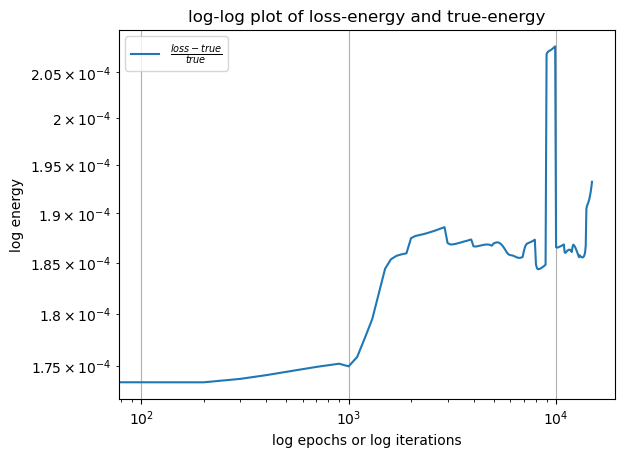

In [33]:
# read in the PINN output file evaluated from HYDRA
import json
jsonfilename = PINN_HISTORY_JSON_FILENAME_REDUCED

# Load history
with open(jsonfilename, "r") as jsonfile:
    history = json.load(jsonfile)

# Extract data
epochs = np.array([row["epoch"] for row in history])
loss_energy = np.array([row["loss_energy"] for row in history])
true_energy = np.array([row["true_energy"] for row in history])
pos = np.array([row["pos"] for row in history])

# Plot
plt.figure()
# plt.plot(epochs, loss_energy-np.min(loss_energy) + 1e-12 ,label='$\\Delta$loss_energy')
# plt.plot(epochs, true_energy-np.min(true_energy) + 1e-12 ,label='$\\Delta$true_energy')
plt.plot(epochs, np.abs((loss_energy - true_energy)/true_energy),label='$\\frac{loss - true}{true}$')
plt.xlabel("log epochs or log iterations")
plt.ylabel("log energy")
plt.title("log-log plot of loss-energy and true-energy")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

In [34]:
from shared_lammps_2D import *

LAMMPS_DIR          =   "./lammps_two_material/"
LAMMPS_TRAJ_FILE    =   LAMMPS_DIR + "two_material.dump"
LAMMPS_ENERGY_LOG   =   LAMMPS_DIR + "two_material.log"

In [35]:
timesteps, lammps_frames = read_lammps_trajectory_xy(LAMMPS_TRAJ_FILE)

print(timesteps.shape)
print(lammps_frames.shape)
# shape: (n_frames, n_atoms, 2)

(151,)
(151, 2450, 2)


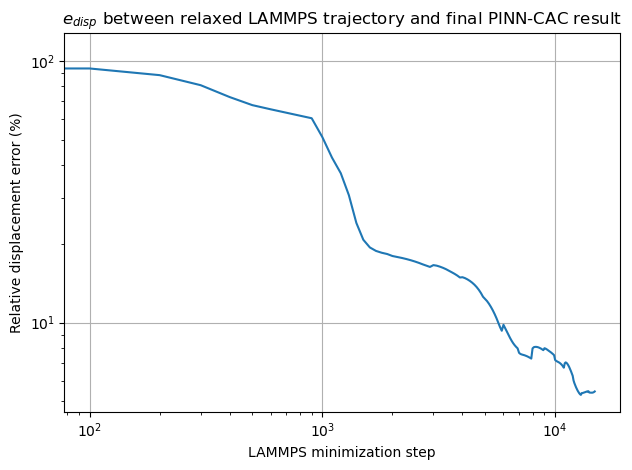

In [36]:
def relative_displacement_error(u_ref, u_pred):
    return np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)

errors = []

for i in range(1,len(pos)):
    u_lammps = lammps_frames[i] - atom_pos
    u_pinn = pos[i]  - atom_pos
    err = relative_displacement_error(u_lammps,u_pinn)
    errors.append(err)
errors = np.array(errors)

plt.figure()
plt.plot(np.arange(len(errors))*100, 100*errors)
plt.xlabel("LAMMPS minimization step")
plt.ylabel("Relative displacement error (%)")
plt.title("$e_{disp}$ between relaxed LAMMPS trajectory and final PINN-CAC result")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [37]:
u_lammps_mags = np.linalg.norm(lammps_frames-atom_pos,axis=2)
u_pinn_mags = np.linalg.norm(pos-atom_pos,axis=2)
relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))

/tmp/ipykernel_2140375/2592136731.py:3: RuntimeWarning: invalid value encountered in divide
  relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))


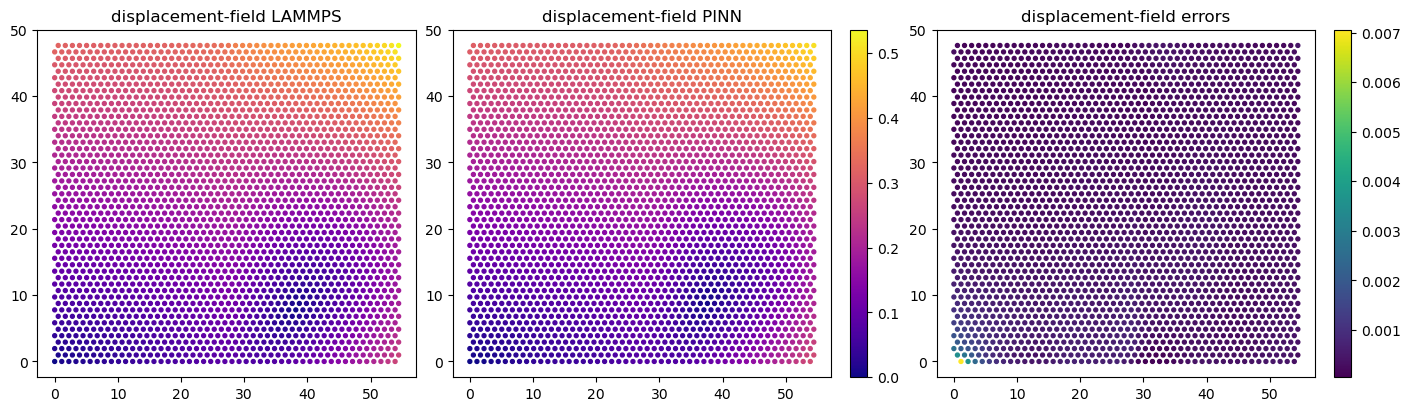

In [38]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

vmin = np.min([np.min(u_pinn_mags[-1]),np.min(u_lammps_mags[-1])])
vmax = np.max([np.max(u_pinn_mags[-1]),np.max(u_lammps_mags[-1])])

scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_lammps_mags[-1],cmap='plasma',s=8,alpha=1,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_pinn_mags[-1],cmap='plasma',s=8,alpha=1,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("displacement-field LAMMPS")
ax2.set_title("displacement-field PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=relative_err_mags[-1],cmap='viridis',s=8,alpha=1,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("displacement-field errors")

plt.show()

In [39]:
# find the bond-length-vectors at all times
bond_lengths_lammps = []
bond_lengths_pinn = []
bond_lengths_errors = []
for i in range(len(pos)):
    err_bond, b_lammps, b_pinn = relative_bond_length_error(
        pos0=atom_pos,
        pos_lammps=lammps_frames[i+1],
        pos_pinn=pos[i],
        spacing=2**(1/6),
    )
    bond_lengths_errors.append(err_bond)
    bond_lengths_lammps.append(b_lammps)
    bond_lengths_pinn.append(b_pinn)

bond_lengths_errors = np.array(bond_lengths_errors)
bond_lengths_lammps = np.array(bond_lengths_lammps)
bond_lengths_pinn = np.array(bond_lengths_pinn)

print(f"bond-length error at final iteration/epoch = {100 * bond_lengths_errors[-1]:.6f}%")

bond-length error at final iteration/epoch = 0.069703%


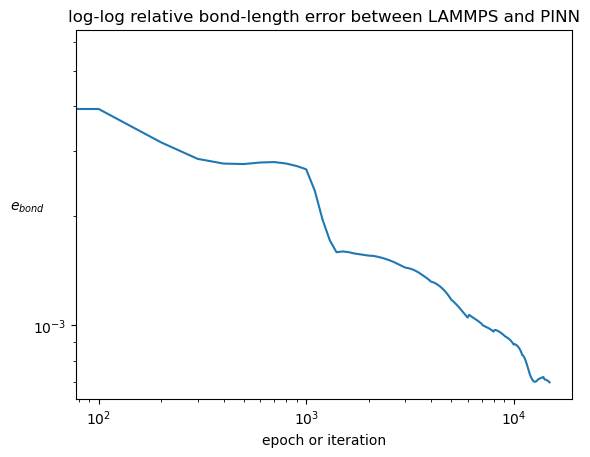

In [40]:
plt.plot(epochs,bond_lengths_errors)
plt.yscale('log')
plt.xscale('log')
plt.title('log-log relative bond-length error between LAMMPS and PINN')
plt.xlabel('epoch or iteration')
plt.ylabel('$e_{bond}$',rotation=0)
plt.show()

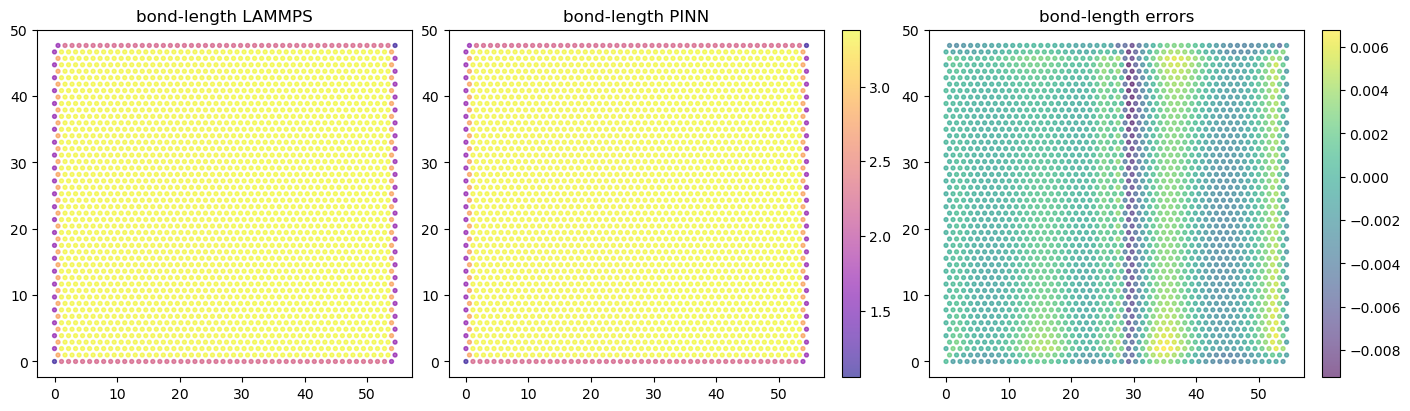

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
vmin = np.min([np.min(bond_lengths_lammps),np.min(bond_lengths_pinn)])
vmax = np.max([np.max(bond_lengths_lammps),np.max(bond_lengths_pinn)])
scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1],cmap='plasma',s=8,alpha=0.6,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("bond-length LAMMPS")
ax2.set_title("bond-length PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1]-bond_lengths_lammps[-1],cmap='viridis',s=8,alpha=0.6,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("bond-length errors")

plt.show()

In [5]:
LAMMPS_ENERGY_LOG

'./lammps_two_material/two_material.log'

In [42]:
steps, pe, c_pairpe, fnorm, fmax = read_lammps_thermo_energy(LAMMPS_ENERGY_LOG)

NOW READING ENERGY LOG ./lammps_two_material/two_material.log


In [ ]:
steps

In [ ]:
c_paire

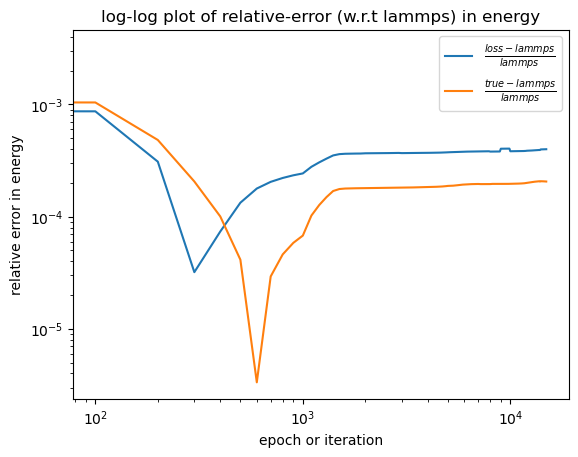

In [58]:
plt.plot(epochs,np.abs((loss_energy-c_pairpe[1:])/c_pairpe[1:]),label='$\\frac{loss - lammps}{lammps}$')
plt.plot(epochs,np.abs((true_energy-c_pairpe[1:])/c_pairpe[1:]),label='$\\frac{true - lammps}{lammps}$')
# plt.plot(epochs,true_energy,label='true-energy')
# plt.plot(epochs,c_pairpe[1:],label='lammps')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()

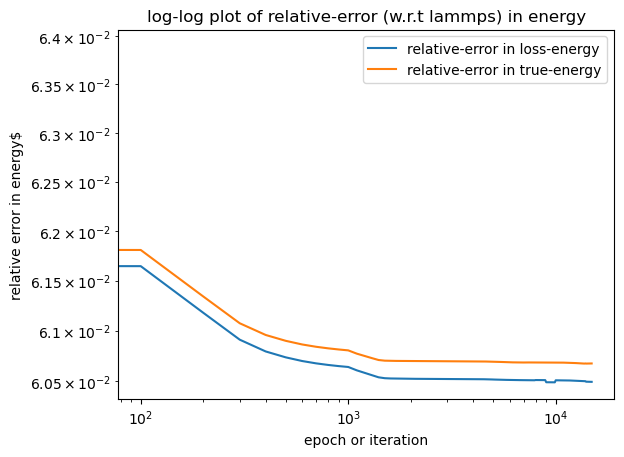

In [60]:
loss_energy_err = np.abs(loss_energy - pe[1:])/np.abs(pe[1:])
true_energy_err = np.abs(true_energy - pe[1:])/np.abs(pe[1:])
plt.plot(epochs,loss_energy_err,label='relative-error in loss-energy')
plt.plot(epochs,true_energy_err,label='relative-error in true-energy')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy$')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()

In [61]:
def make_force_bc_right_boundary_band(atom_pos,force_per_atom,band_width,):
    f_ext = np.zeros_like(atom_pos)

    xmax = atom_pos[:, 0].max()
    right_band = atom_pos[:, 0] >= xmax - band_width

    f_ext[right_band, :] = force_per_atom

    return f_ext, right_band

f_ext_np, right_boundary_band = make_force_bc_right_boundary_band(atom_pos=atom_pos,force_per_atom=FORCE_PER_ATOM,band_width=BANDWIDTH* LATTICE_SPACING,)

In [62]:
lammps_total_corrected = pe + np.sum(f_ext_np * atom_pos)

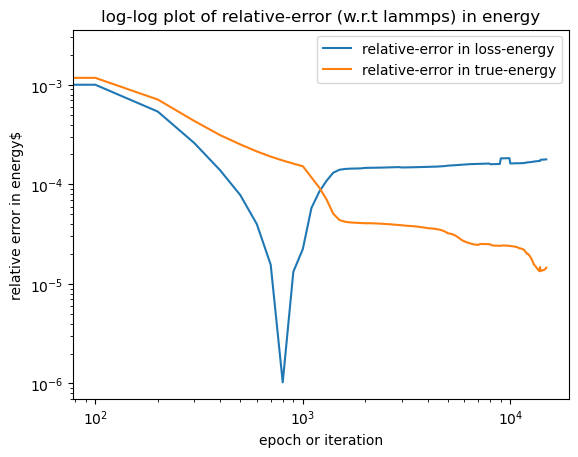

In [63]:
loss_energy_err = np.abs(loss_energy - lammps_total_corrected[:-1])/np.abs(lammps_total_corrected[:-1])
true_energy_err = np.abs(true_energy - lammps_total_corrected[:-1])/np.abs(lammps_total_corrected[:-1])
plt.plot(epochs,loss_energy_err,label='relative-error in loss-energy')
plt.plot(epochs,true_energy_err,label='relative-error in true-energy')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy$')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()

In [ ]:
force_offset = np.sum(f_ext_np * atom_pos)
print("force offset sum f dot X:", force_offset)
print("LAMMPS corrected energy:", pe + force_offset)

In [ ]:
np.min(pe)

In [71]:
PINN_HISTORY_JSON_FILENAME_REDUCED = "./IL1_BL3/pinn-history-2d-piecewise-neumann-reduced-IL1-BL3-TRIAL7.json"
load_pinn_energy_history(PINN_HISTORY_JSON_FILENAME_REDUCED)

NameError: name 'load_pinn_energy_history' is not defined

Selected IL=1, BL=3, 
full: found 10 trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
reduced: found 10 trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Rejecting reduced trial 4 as a final-energy outlier: |E_final - E_LAMMPS| = 3.19250288e+02
Rejecting reduced trial 5 as a final-energy outlier: |E_final - E_LAMMPS| = 2.71830964e+02
Rejecting reduced trial 10 as a final-energy outlier: |E_final - E_LAMMPS| = 2.71374936e+02
all_epochs [    0.   100.   200.   300.   400.   500.   600.   700.   800.   900.
  1000.  1100.  1200.  1300.  1400.  1500.  1600.  1700.  1800.  1900.
  2000.  2100.  2200.  2300.  2400.  2500.  2600.  2700.  2800.  2900.
  3000.  3100.  3200.  3300.  3400.  3500.  3600.  3700.  3800.  3900.
  4000.  4100.  4200.  4300.  4400.  4500.  4600.  4700.  4800.  4900.
  5000.  5100.  5200.  5300.  5400.  5500.  5600.  5700.  5800.  5900.
  6000.  6100.  6200.  6300.  6400.  6500.  6600.  6700.  6800.  6900.
  7000.  7100.  7200.  7300.  7400.  7500.  7600.  7700.  7800.  7900.
  8000.  810

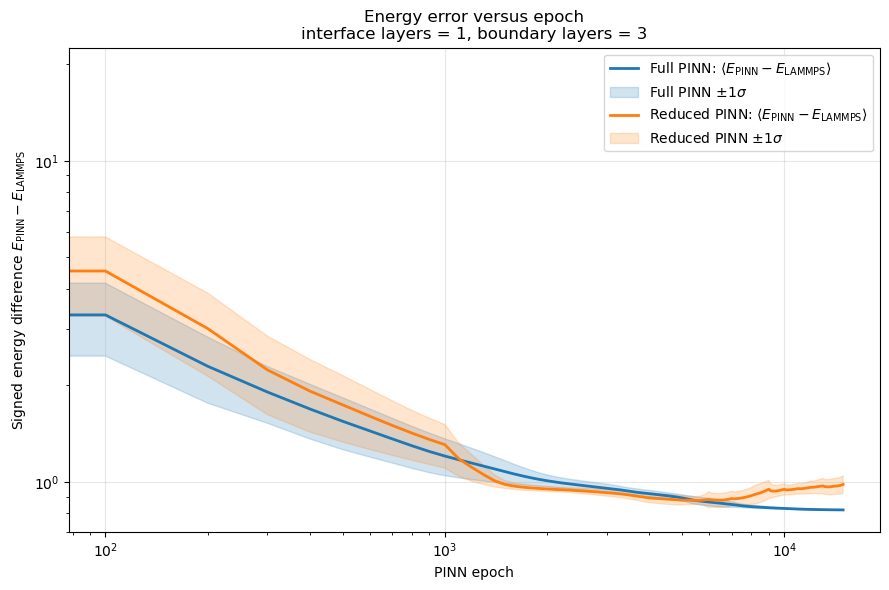

In [70]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

HISTORY_DIR = Path("./IL1_BL3")

INTERFACE_LAYERS = 1
BOUNDARY_LAYERS = 3

N_EXPECTED_TRIALS = 10

# Use the final LAMMPS pair/internal energy.
#
# Recommended source:
#     c_pairpe from:
#         compute pairpe all pe pair
#         thermo_style custom step pe c_pairpe ...
#
# Replace this with your actual final LAMMPS pair energy.
LAMMPS_FINAL_ENERGY = np.min(pe)

# Energy field stored in every PINN history frame.
#
# Use "true_energy" when comparing against LAMMPS pair/internal energy.
PINN_ENERGY_KEY = "true_energy"

# Reject an entire trial when its final energy error is unusually large.
REJECT_FINAL_ENERGY_OUTLIERS = True

# Modified z-score cutoff used within full and reduced groups separately.
OUTLIER_Z_THRESHOLD = 3.5

# Plot absolute energy difference rather than signed difference.
USE_ABSOLUTE_ERROR = False

OUTPUT_FILE = f"energy_error_vs_epoch_IL{INTERFACE_LAYERS}_BL{BOUNDARY_LAYERS}.png"


# ---------------------------------------------------------------------------
# Filename handling
# ---------------------------------------------------------------------------

FILENAME_RE = re.compile(
    r"^pinn-history-2d-piecewise-neumann-"
    r"(?P<kind>full|reduced)-"
    r"IL(?P<interface_layers>\d+)-"
    r"BL(?P<boundary_layers>\d+)-"
    r"TRIAL(?P<trial>\d+)\.json$"
)


def parse_history_filename(path):
    match = FILENAME_RE.match(path.name)

    if match is None:
        return None

    fields = match.groupdict()

    return {
        "path": path,
        "kind": fields["kind"],
        "interface_layers": int(fields["interface_layers"]),
        "boundary_layers": int(fields["boundary_layers"]),
        "trial": int(fields["trial"]),
    }


def find_selected_histories():
    """
    Return:

        {
            "full": {trial_number: path},
            "reduced": {trial_number: path},
        }
    """
    selected = {
        "full": {},
        "reduced": {},
    }

    for path in sorted(HISTORY_DIR.glob("*.json")):
        metadata = parse_history_filename(path)

        if metadata is None:
            continue

        if metadata["interface_layers"] != INTERFACE_LAYERS:
            continue

        if metadata["boundary_layers"] != BOUNDARY_LAYERS:
            continue

        kind = metadata["kind"]
        trial = metadata["trial"]

        if trial in selected[kind]:
            raise RuntimeError(
                f"Duplicate {kind} history for trial {trial}:\n"
                f"  {selected[kind][trial]}\n"
                f"  {path}"
            )

        selected[kind][trial] = path

    return selected


# ---------------------------------------------------------------------------
# History loading
# ---------------------------------------------------------------------------

def load_energy_history(path, energy_key="true_energy"):
    """
    Load epoch and energy arrays from one PINN JSON history.
    """
    try:
        with path.open("r") as stream:
            history = json.load(stream)
    except Exception as exc:
        raise RuntimeError(f"Could not load {path}: {exc}") from exc

    if not isinstance(history, list) or len(history) == 0:
        raise ValueError(f"History is empty or invalid: {path}")

    epochs = []
    energies = []

    for frame_index, frame in enumerate(history):
        if "epoch" not in frame:
            raise KeyError(
                f"Frame {frame_index} in {path} has no 'epoch' key."
            )

        if energy_key not in frame:
            raise KeyError(
                f"Frame {frame_index} in {path} has no "
                f"'{energy_key}' key."
            )

        epoch = float(frame["epoch"])
        energy = float(frame[energy_key])

        if not np.isfinite(epoch) or not np.isfinite(energy):
            continue

        epochs.append(epoch)
        energies.append(energy)

    epochs = np.asarray(epochs, dtype=np.float64)
    energies = np.asarray(energies, dtype=np.float64)

    if len(epochs) == 0:
        raise ValueError(f"No finite energy values were found in {path}")

    # Ensure increasing epoch order.
    order = np.argsort(epochs)
    epochs = epochs[order]
    energies = energies[order]

    # Remove duplicate epochs, keeping the final occurrence.
    unique_epochs, reverse_indices = np.unique(
        epochs[::-1],
        return_index=True,
    )

    keep = len(epochs) - 1 - reverse_indices
    keep = np.sort(keep)

    return epochs[keep], energies[keep]


# ---------------------------------------------------------------------------
# Robust trial rejection
# ---------------------------------------------------------------------------

def find_upper_outliers(values_by_trial, z_threshold=3.5):
    """
    Detect trials with unusually large final absolute energy errors.

    Parameters
    ----------
    values_by_trial : dict[int, float]
        trial -> final absolute energy error

    Returns
    -------
    rejected : set[int]
        Trials classified as upper outliers.
    """
    if len(values_by_trial) < 4:
        return set()

    trials = np.asarray(list(values_by_trial.keys()), dtype=int)
    values = np.asarray(list(values_by_trial.values()), dtype=float)

    median = np.median(values)
    mad = np.median(np.abs(values - median))

    if mad > 0.0:
        modified_z = 0.6744897501960817 * (values - median) / mad
        return set(trials[modified_z > z_threshold].tolist())

    # Fallback when MAD is zero.
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1

    if iqr <= 0.0:
        return set()

    upper_limit = q3 + 1.5 * iqr

    return set(trials[values > upper_limit].tolist())


# ---------------------------------------------------------------------------
# Epoch alignment and statistics
# ---------------------------------------------------------------------------

def common_epoch_grid(histories):
    """
    Construct a common epoch grid from the intersection of the epoch ranges.

    Histories are interpolated onto this grid so trials can have slightly
    different saved epochs or terminate at different points.
    """
    minimum_common_epoch = max(
        epochs[0]
        for epochs, _ in histories.values()
    )

    maximum_common_epoch = min(
        epochs[-1]
        for epochs, _ in histories.values()
    )

    if maximum_common_epoch < minimum_common_epoch:
        raise RuntimeError("Trial histories have no overlapping epoch range.")

    all_epochs = np.unique(
        np.concatenate(
            [
                epochs[
                    (epochs >= minimum_common_epoch)
                    & (epochs <= maximum_common_epoch)
                ]
                for epochs, _ in histories.values()
            ]
        )
    )

    print("all_epochs",all_epochs)
    return all_epochs


def interpolate_energy_errors(histories, epoch_grid, reference_energy):
    """
    Interpolate every trial onto epoch_grid and subtract reference_energy.

    Returns
    -------
    trial_numbers : ndarray, shape (n_trials,)
    errors : ndarray, shape (n_trials, n_epochs)
    """
    trial_numbers = sorted(histories)
    error_rows = []

    for trial in trial_numbers:
        epochs, energies = histories[trial]

        interpolated_energy = np.interp(epoch_grid,epochs,energies,)

        error = interpolated_energy - reference_energy

        if USE_ABSOLUTE_ERROR:
            error = np.abs(error)

        error_rows.append(error)

    return (
        np.asarray(trial_numbers, dtype=int),
        np.asarray(error_rows, dtype=np.float64),
    )


def mean_and_std(values):
    """
    Population mean and sample standard deviation across trials.

    ddof=1 gives the usual sample standard deviation when at least two
    trials remain.
    """
    mean = np.nanmean(values, axis=0)

    if values.shape[0] >= 2:
        std = np.nanstd(values, axis=0, ddof=1)
    else:
        std = np.zeros_like(mean)

    return mean, std


# ---------------------------------------------------------------------------
# Main analysis
# ---------------------------------------------------------------------------

def main():
    selected = find_selected_histories()

    print(
        f"Selected IL={INTERFACE_LAYERS}, "
        f"BL={BOUNDARY_LAYERS}, "
    )

    for kind in ("full", "reduced"):
        found_trials = sorted(selected[kind])

        print(
            f"{kind}: found {len(found_trials)} trials: "
            f"{found_trials}"
        )

        if len(found_trials) == 0:
            raise RuntimeError(
                f"No {kind} histories found for the selected parameters."
            )

    histories = {
        "full": {},
        "reduced": {},
    }

    invalid_trials = {
        "full": set(),
        "reduced": set(),
    }

    for kind in ("full", "reduced"):
        for trial, path in sorted(selected[kind].items()):
            try:
                histories[kind][trial] = load_energy_history(
                    path,
                    energy_key=PINN_ENERGY_KEY,
                )
            except Exception as exc:
                invalid_trials[kind].add(trial)
                print(
                    f"Rejecting invalid {kind} trial {trial}: {exc}"
                )

    # Reject invalid trials independently. Full and reduced averages do not
    # need to contain exactly the same trial numbers.
    for kind in ("full", "reduced"):
        for trial in invalid_trials[kind]:
            histories[kind].pop(trial, None)

    # ---------------------------------------------------------------
    # Optional final-energy outlier rejection
    # ---------------------------------------------------------------

    rejected_outliers = {
        "full": set(),
        "reduced": set(),
    }

    if REJECT_FINAL_ENERGY_OUTLIERS:
        for kind in ("full", "reduced"):
            final_absolute_errors = {
                trial: abs(energies[-1] - LAMMPS_FINAL_ENERGY)
                for trial, (_, energies) in histories[kind].items()
            }

            rejected_outliers[kind] = find_upper_outliers(
                final_absolute_errors,
                z_threshold=OUTLIER_Z_THRESHOLD,
            )

            for trial in sorted(rejected_outliers[kind]):
                final_error = final_absolute_errors[trial]

                print(
                    f"Rejecting {kind} trial {trial} as a final-energy "
                    f"outlier: |E_final - E_LAMMPS| = "
                    f"{final_error:.8e}"
                )

                histories[kind].pop(trial)

    for kind in ("full", "reduced"):
        if len(histories[kind]) == 0:
            raise RuntimeError(
                f"No valid {kind} trials remain after filtering."
            )

    # It is preferable to use one common grid for both curves so that the
    # plotted epochs match exactly.
    combined_histories = {}

    for kind in ("full", "reduced"):
        for trial, value in histories[kind].items():
            combined_histories[(kind, trial)] = value

    epoch_grid = common_epoch_grid(combined_histories)

    full_trials, full_errors = interpolate_energy_errors(histories["full"],epoch_grid,LAMMPS_FINAL_ENERGY,)

    reduced_trials, reduced_errors = interpolate_energy_errors(histories["reduced"],epoch_grid,LAMMPS_FINAL_ENERGY,)

    full_mean, full_std = mean_and_std(full_errors)
    reduced_mean, reduced_std = mean_and_std(reduced_errors)
    full_mean -= 270
    reduced_mean -= 270

    print()
    print(f"Full trials used:    {full_trials.tolist()}")
    print(f"Reduced trials used: {reduced_trials.tolist()}")
    print(f"Common epoch range:  {epoch_grid[0]} to {epoch_grid[-1]}")
    print(f"LAMMPS reference energy: {LAMMPS_FINAL_ENERGY:.16e}")

    # ---------------------------------------------------------------
    # Plot
    # ---------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(9, 6))

    full_line = ax.plot(
        epoch_grid,
        full_mean,
        linewidth=2.0,
        label=(
            r"Full PINN: "
            r"$\langle E_{\mathrm{PINN}}-E_{\mathrm{LAMMPS}}\rangle$"
        ),
    )[0]

    ax.fill_between(
        epoch_grid,
        full_mean - full_std,
        full_mean + full_std,
        alpha=0.20,
        color=full_line.get_color(),
        label=r"Full PINN $\pm 1\sigma$",
    )

    reduced_line = ax.plot(
        epoch_grid,
        reduced_mean,
        linewidth=2.0,
        label=(
            r"Reduced PINN: "
            r"$\langle E_{\mathrm{PINN}}-E_{\mathrm{LAMMPS}}\rangle$"
        ),
    )[0]

    ax.fill_between(
        epoch_grid,
        reduced_mean - reduced_std,
        reduced_mean + reduced_std,
        alpha=0.20,
        color=reduced_line.get_color(),
        label=r"Reduced PINN $\pm 1\sigma$",
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    # # Zero means exact agreement with the LAMMPS reference energy.
    # ax.axhline(
    #     1e-1,
    #     linewidth=1.0,
    #     linestyle="--",
    #     label="LAMMPS reference",
    # )

    ax.set_xlabel("PINN epoch")

    if USE_ABSOLUTE_ERROR:
        ax.set_ylabel(
            r"Absolute energy error "
            r"$|E_{\mathrm{PINN}}-E_{\mathrm{LAMMPS}}|$"
        )
    else:
        ax.set_ylabel(
            r"Signed energy difference "
            r"$E_{\mathrm{PINN}}-E_{\mathrm{LAMMPS}}$"
        )

    ax.set_title(
        "Energy error versus epoch\n"
        f"interface layers = {INTERFACE_LAYERS}, "
        f"boundary layers = {BOUNDARY_LAYERS}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        OUTPUT_FILE,
        dpi=200,
        bbox_inches="tight",
    )

    print(f"Wrote plot: {OUTPUT_FILE}")

    plt.show()


if __name__ == "__main__":
    main()

# have to rewrite a bunch of the code actually. chatgp pointed out a bunch of errors. 
# i should alos really really really re-organize my folder. this is getting too cluttered. having to scroll up and down